In [18]:
%matplotlib widget

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [20]:
DATA_DIR = Path("../data")
files = sorted(DATA_DIR.glob("*.csv"))
for f in files:
    print(f.name)

00_index_suma_normal_20260313_162501.csv
01_middle_suma_normal_20260313_162555.csv
03_middle_pavan_normal_20260313_194335.csv
04_index_pavan_normal_20260313_194443.csv
05_middle_suma_hyper_20260406_162451.csv
06_middle_pavan_normal01_20260406_162928.csv
07_middle_pavan_normal_appleHR76_20260406_163030.csv
08_middle_pavan_hyper_appleHR153_143_20260406_163327.csv
09_middle_pavan_test_post_hyper_appleHR84_20260406_163527.csv
10_middle_pavan_breathing_motion_appleHR89_20260406_163735.csv
11_middle_pavan_hyper01_appleHR166_139_20260406_164521.csv


In [21]:
df = pd.read_csv(DATA_DIR / "11_middle_pavan_hyper01_appleHR166_139_20260406_164521.csv")
df['time_s'] = df['timestamp_ms'] / 1000.0
print(f"\nSamples : {len(df)}")
print(f"Duration: {df['time_s'].iloc[-1]:.1f}s")
print(f"Est. rate: {len(df) / df['time_s'].iloc[-1]:.1f} Hz")


Samples : 1830
Duration: 30.0s
Est. rate: 61.0 Hz


In [22]:
fingerONthreshold = 0.1
mask = df['time_s'] > fingerONthreshold
first_crossing = mask.idxmax() if mask.any() else None 
df_offset = df.loc[first_crossing:,:]
df_offset.reset_index()

,index,sample_index,timestamp_ms,ir,red,time_s
0,268,268,120,164875,85522,0.120
1,269,269,139,164895,85542,0.139
2,270,270,158,164914,85557,0.158
3,271,271,177,164947,85561,0.177
4,272,272,196,164954,85564,0.196
...,...,...,...,...,...,...
1557,1825,1825,29916,160022,84428,29.916
1558,1826,1826,29935,159886,84380,29.935
1559,1827,1827,29955,159830,84369,29.955
1560,1828,1828,29974,159749,84345,29.974


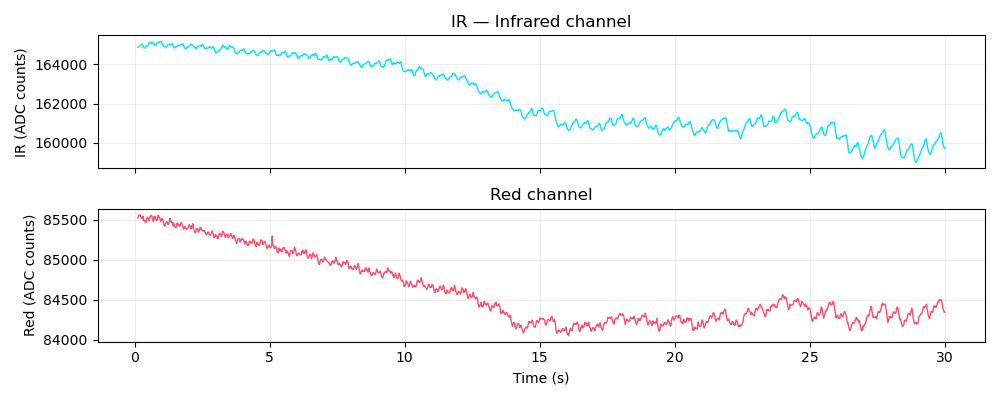

In [23]:
# ── CELL 4 — Plot raw IR and Red ──────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
 
ax1.plot(df_offset['time_s'], df_offset['ir'],  color='#00e5ff', lw=1)
ax1.set_ylabel('IR (ADC counts)')
ax1.set_title('IR — Infrared channel')
ax1.grid(True, alpha=0.2)
 
ax2.plot(df_offset['time_s'], df_offset['red'], color='#ff4d6d', lw=1)
ax2.set_ylabel('Red (ADC counts)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Red channel')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## HR Estimation — `hr_estimation.py`

Functions migrated from `Interview-notebook.ipynb` and adapted for the ESP32/MAX30102 data format.

In [29]:
import importlib
import hr_estimation
importlib.reload(hr_estimation)

from hr_estimation import bandpass_filter, est_window_hr, kalman_smooth, est_hr

### Single-file test

Using `07_middle_pavan_normal_appleHR76` as a sanity check — the filename tells us the Apple Watch reference HR was **76 BPM**.

In [35]:
TEST_FILE = DATA_DIR / "11_middle_pavan_hyper01_appleHR166_139_20260406_164521.csv"
df_test = pd.read_csv(TEST_FILE)
df_test['time_s'] = df_test['timestamp_ms'] / 1000.0

fs_detected = 1000.0 / np.median(np.diff(df_test['timestamp_ms'].values))
print(f"Detected sampling rate : {fs_detected:.1f} Hz")
print(f"Recording duration     : {df_test['time_s'].iloc[-1]:.1f} s")
print(f"Samples                : {len(df_test)}")

hr_result = est_hr(df_test)
print(f"\nMedian estimated HR : {hr_result['hr_bpm'].median():.1f} BPM  (Apple Watch ref: 76 BPM)")

Detected sampling rate : 52.6 Hz
Recording duration     : 30.0 s
Samples                : 1830

Median estimated HR : 154.1 BPM  (Apple Watch ref: 76 BPM)


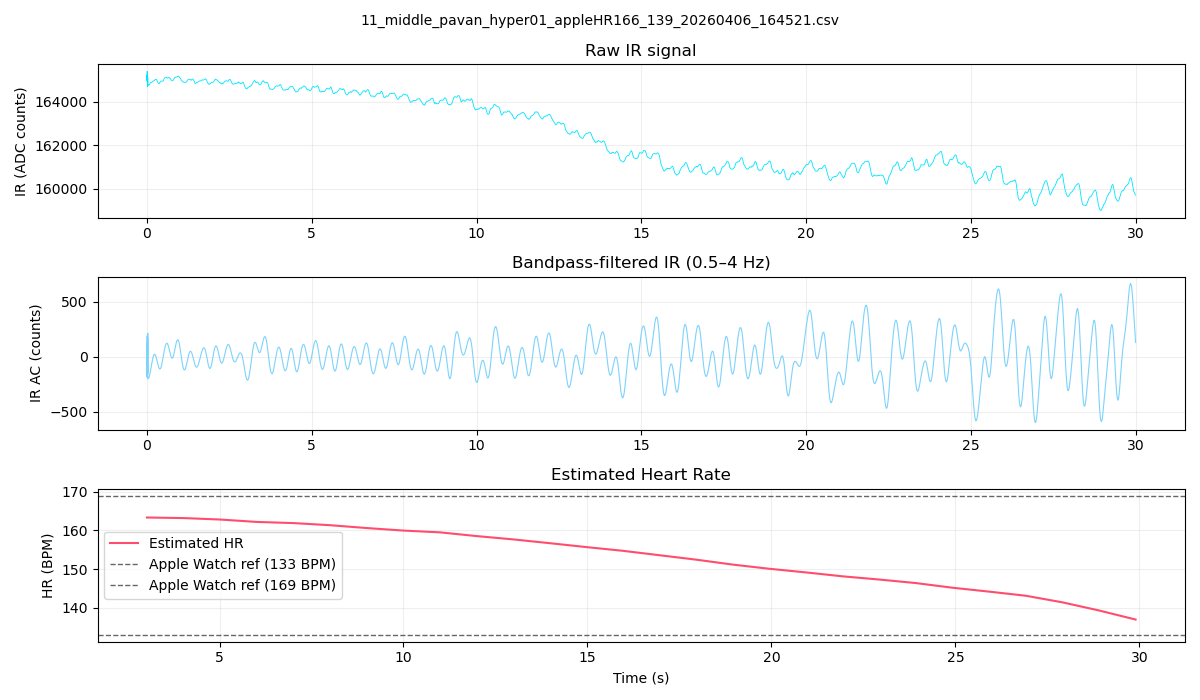

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)

# Raw IR
axes[0].plot(df_test['time_s'], df_test['ir'], color='#00e5ff', lw=0.6)
axes[0].set_ylabel('IR (ADC counts)')
axes[0].set_title('Raw IR signal')
axes[0].grid(True, alpha=0.2)

# Bandpass-filtered IR
ir_filt = bandpass_filter(df_test['ir'].values, fs=fs_detected)
axes[1].plot(df_test['time_s'], ir_filt, color='#7dd3fc', lw=0.8)
axes[1].set_ylabel('IR AC (counts)')
axes[1].set_title('Bandpass-filtered IR (0.5–4 Hz)')
axes[1].grid(True, alpha=0.2)

# Estimated HR over time
axes[2].plot(hr_result.index / 1000, hr_result['hr_bpm'], color='#ff4d6d', lw=1.5, label='Estimated HR')
axes[2].axhline(133, color='black', lw=1, ls='--', alpha=0.6, label='Apple Watch ref (133 BPM)')
axes[2].axhline(169, color='black', lw=1, ls='--', alpha=0.6, label='Apple Watch ref (169 BPM)')
axes[2].set_ylabel('HR (BPM)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Estimated Heart Rate')
axes[2].legend()
axes[2].grid(True, alpha=0.2)

plt.suptitle(TEST_FILE.name, fontsize=10)
plt.tight_layout()
plt.show()

### Batch test — all files

Files that contain `appleHR<N>` in the name carry an Apple Watch reference. We compare the median estimated HR against it.

In [38]:
import re

results = []
for f in sorted(DATA_DIR.glob("*.csv")):
    df_f = pd.read_csv(f)
    hr_f = est_hr(df_f)
    median_hr = hr_f['hr_bpm'].median()

    # extract Apple Watch reference HR from filename if present (e.g. appleHR76 or appleHR153_143)
    match = re.search(r'appleHR(\d+)', f.name)
    ref_hr_val = int(match.group(1)) if match else None
    error = abs(median_hr - ref_hr_val) if ref_hr_val else None

    results.append({
        'file': f.name,
        'estimated_hr': round(median_hr, 1),
        'apple_ref_hr': ref_hr_val,
        'abs_error_bpm': round(error, 1) if error is not None else None,
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                                                          file  estimated_hr  apple_ref_hr  abs_error_bpm
                      00_index_suma_normal_20260313_162501.csv          82.9           NaN            NaN
                     01_middle_suma_normal_20260313_162555.csv          73.0           NaN            NaN
                    03_middle_pavan_normal_20260313_194335.csv          81.9           NaN            NaN
                     04_index_pavan_normal_20260313_194443.csv          77.4           NaN            NaN
                      05_middle_suma_hyper_20260406_162451.csv          95.3           NaN            NaN
                  06_middle_pavan_normal01_20260406_162928.csv          77.2           NaN            NaN
          07_middle_pavan_normal_appleHR76_20260406_163030.csv          76.5          76.0            0.5
      08_middle_pavan_hyper_appleHR153_143_20260406_163327.csv         135.6         153.0           17.4
 09_middle_pavan_test_post_hyper_appleHR84_202